# FraudLens — EDA & Model Evaluation

This notebook explores the transaction feature set produced by the streaming
pipeline and walks through model selection for the fraud classifier shipped
in `training/train.py`.

**Contents**
1. Load feature data (same schema as the offline store)
2. Exploratory data analysis — class balance, feature distributions, correlations
3. Baseline model (Logistic Regression) vs. XGBoost
4. Evaluation — ROC/PR curves, confusion matrix, feature importance, calibration
5. Threshold selection using a cost-based business framing


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, brier_score_loss,
)
from sklearn.calibration import calibration_curve
import xgboost as xgb

from streaming.features import FEATURE_COLUMNS, LABEL_COLUMN
from training.train import generate_synthetic_fallback

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_SEED = 42


## 1. Load Feature Data

We use the same `generate_synthetic_fallback` generator that `training/train.py`
falls back to when no data has streamed through yet — this keeps the notebook
reproducible without requiring a live Kafka/Spark/Redis stack, while using
the exact same feature schema (`FEATURE_COLUMNS`) served in production.

In [2]:
df = generate_synthetic_fallback(n_rows=20_000, fraud_rate=0.03)
print(f"Shape: {df.shape}")
df.head()


Shape: (20000, 9)


,txn_count_1h,txn_amount_sum_1h,txn_amount_avg_1h,txn_amount_max_1h,txn_count_24h,txn_amount_avg_24h,distinct_merchant_categories_1h,amount_zscore_vs_24h,is_fraud_label
0,5,51.211106,36.427227,114.813995,11,58.802828,1,-0.863928,0
1,5,15.132730,63.082736,29.892490,15,38.354498,3,-0.312368,0
2,5,36.130699,84.802309,83.101232,7,102.988844,2,-1.595381,0
3,5,121.019146,227.496598,53.686418,6,52.625707,1,1.581289,0
4,1,315.923401,19.457173,70.261948,9,63.273762,3,-0.909060,0


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
txn_count_1h,20000.0,2.605700,1.726608,0.000000,1.000000,2.000000,4.000000,14.000000
txn_amount_sum_1h,20000.0,95.203439,76.797728,0.596083,43.763600,76.371700,125.054127,1366.377258
txn_amount_avg_1h,20000.0,47.600818,41.691698,0.270222,21.329978,37.774667,61.906340,729.952587
txn_amount_max_1h,20000.0,94.487035,74.897087,1.217609,47.747684,78.485187,121.003478,1064.190716
txn_count_24h,20000.0,9.086350,3.053811,0.000000,7.000000,9.000000,11.000000,24.000000
txn_amount_avg_24h,20000.0,53.037941,38.698447,0.199128,25.204513,44.158457,71.062172,597.542070
distinct_merchant_categories_1h,20000.0,2.020700,0.856626,1.000000,1.000000,2.000000,3.000000,5.000000
amount_zscore_vs_24h,20000.0,0.353132,1.389047,-5.097031,-0.567451,0.319944,1.246847,7.744847
is_fraud_label,20000.0,0.030000,0.170591,0.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
counts = df[LABEL_COLUMN].value_counts()

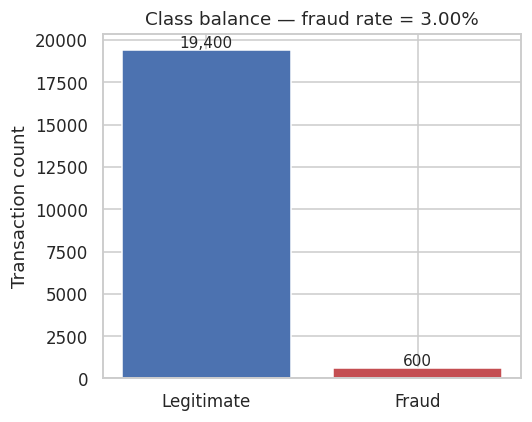

In [4]:
fraud_rate = df[LABEL_COLUMN].mean()
counts = df[LABEL_COLUMN].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Legitimate", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Transaction count")
ax.set_title(f"Class balance — fraud rate = {fraud_rate:.2%}")
for b in bars:
    ax.annotate(f"{int(b.get_height()):,}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


### 2.2 Feature distributions by class

The strongest signals should visibly separate fraud from legitimate activity.
`amount_zscore_vs_24h` and transaction velocity (`txn_count_1h`) are the
features we'd expect to matter most, based on how fraud is injected in the
producer (`producer/simulate_transactions.py`).

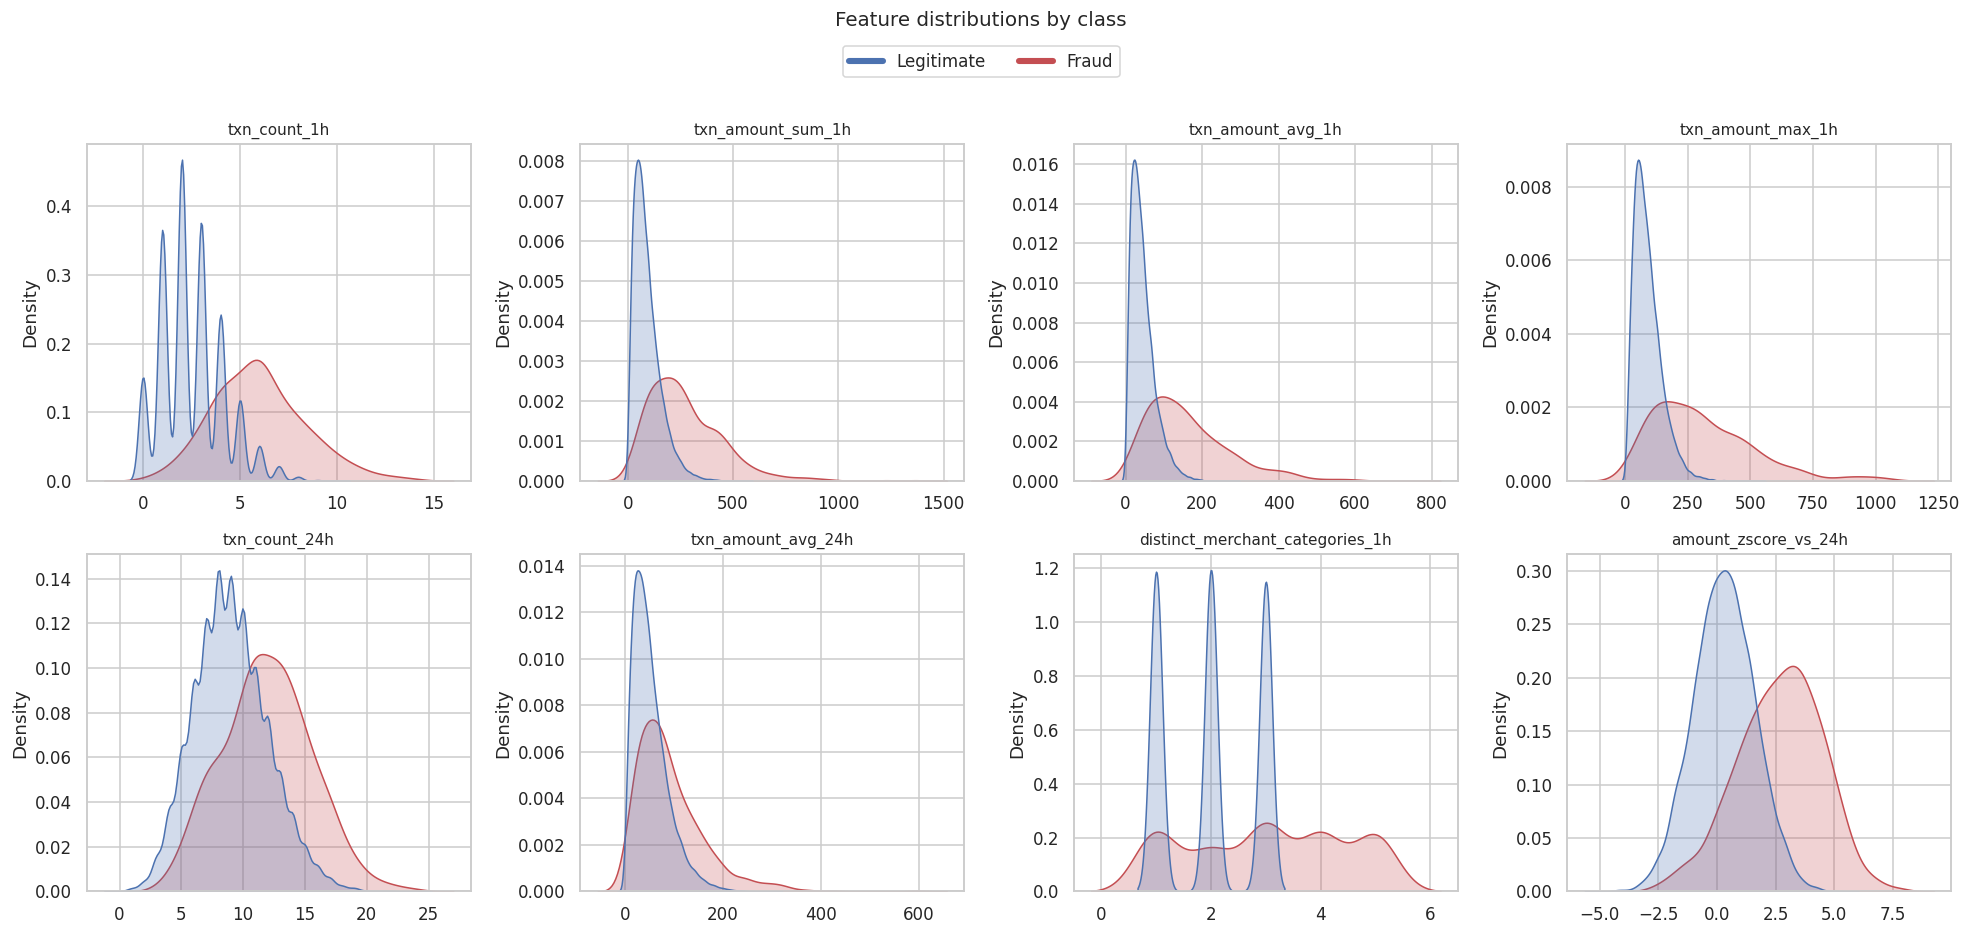

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLUMNS):
    sns.kdeplot(data=df, x=col, hue=LABEL_COLUMN, fill=True, common_norm=False,
                palette={0: "#4C72B0", 1: "#C44E52"}, ax=ax, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

handles = [plt.Line2D([0], [0], color=c, lw=4) for c in ["#4C72B0", "#C44E52"]]
fig.legend(handles, ["Legitimate", "Fraud"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Feature distributions by class", y=1.06, fontsize=13)
plt.tight_layout()
plt.show()


### 2.3 Feature correlation

Checking for multicollinearity — `txn_amount_sum_1h`, `txn_amount_avg_1h`,
and `txn_amount_max_1h` are derived from the same underlying window and are
expected to correlate; tree-based models like XGBoost are robust to this,
but it's worth knowing before trying a linear baseline.

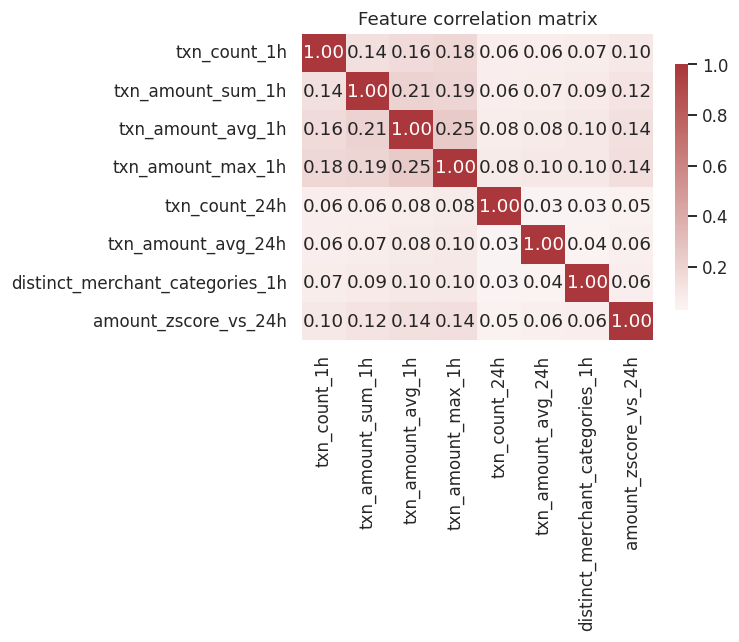

In [6]:
corr = df[FEATURE_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()


## 3. Baseline vs. XGBoost

We compare a simple, interpretable Logistic Regression baseline against the
XGBoost model actually shipped in `training/train.py`. The baseline exists to
answer one question: *is the extra complexity of XGBoost actually earning its
keep?*

In [7]:
X = df[FEATURE_COLUMNS]
y = df[LABEL_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

baseline = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline.fit(X_train, y_train)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    random_state=RANDOM_SEED,
)
xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Trained baseline (Logistic Regression) and XGBoost on identical splits.")


Trained baseline (Logistic Regression) and XGBoost on identical splits.


## 4. Evaluation

### 4.1 ROC and Precision-Recall curves

For a task this imbalanced, **PR-AUC is the metric that matters** — ROC-AUC
can look deceptively good even for a weak model when negatives dominate.

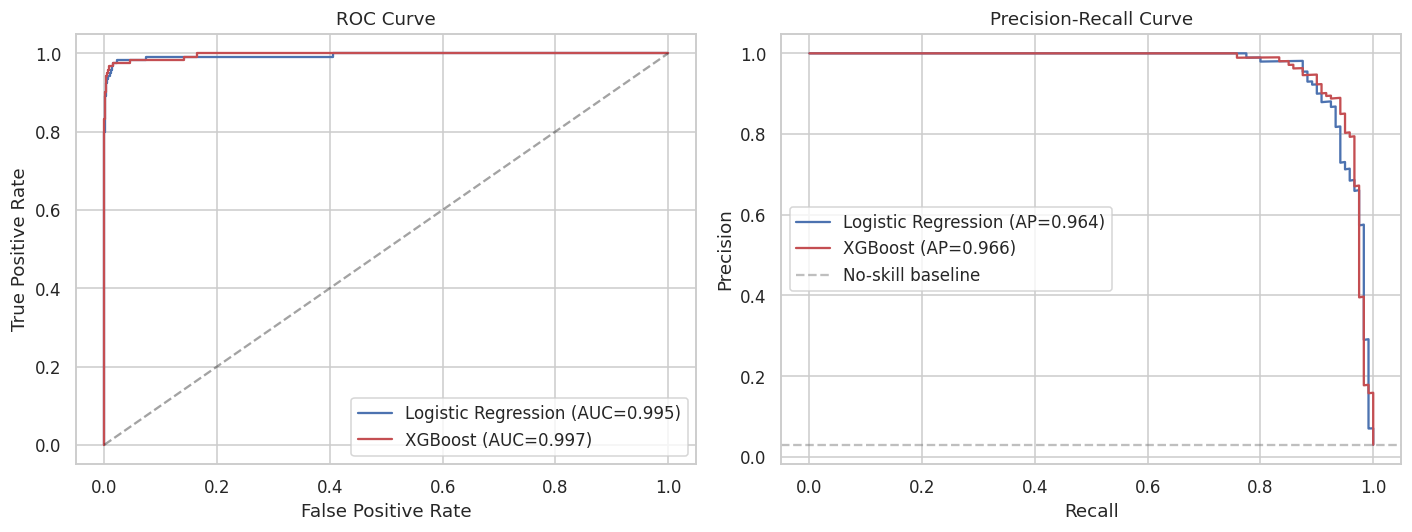

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba, color in [("Logistic Regression", baseline_proba, "#4C72B0"),
                             ("XGBoost", xgb_proba, "#C44E52")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=color)

    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

axes[1].axhline(y=y_test.mean(), color="gray", linestyle="--", alpha=0.5, label="No-skill baseline")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

plt.tight_layout()
plt.show()


### 4.2 Confusion matrix at the production threshold

Using the same `FRAUD_SCORE_THRESHOLD` default (0.75) as `api/scoring.py`, so
this evaluation reflects the actual decision boundary in production, not an
arbitrary 0.5 cutoff.

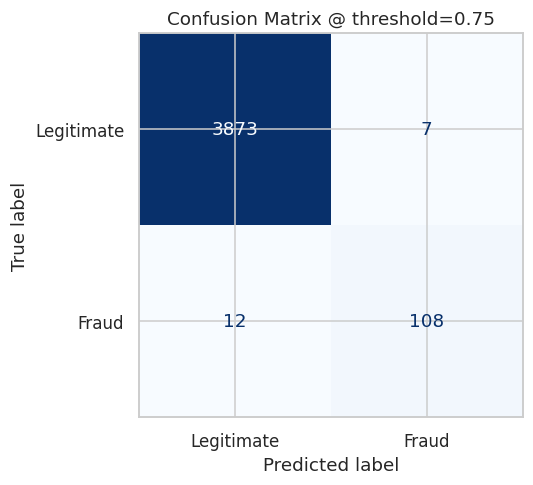

Precision: 0.939  Recall: 0.900  False positive rate: 0.0018


In [9]:
from api.scoring import FRAUD_SCORE_THRESHOLD

y_pred = (xgb_proba >= FRAUD_SCORE_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Fraud"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix @ threshold={FRAUD_SCORE_THRESHOLD}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}  False positive rate: {fp/(fp+tn):.4f}")


### 4.3 Feature importance

Sanity check: does the model actually lean on the signals we designed it to
lean on (`amount_zscore_vs_24h`, transaction velocity), or is it picking up
on something spurious in the synthetic data?

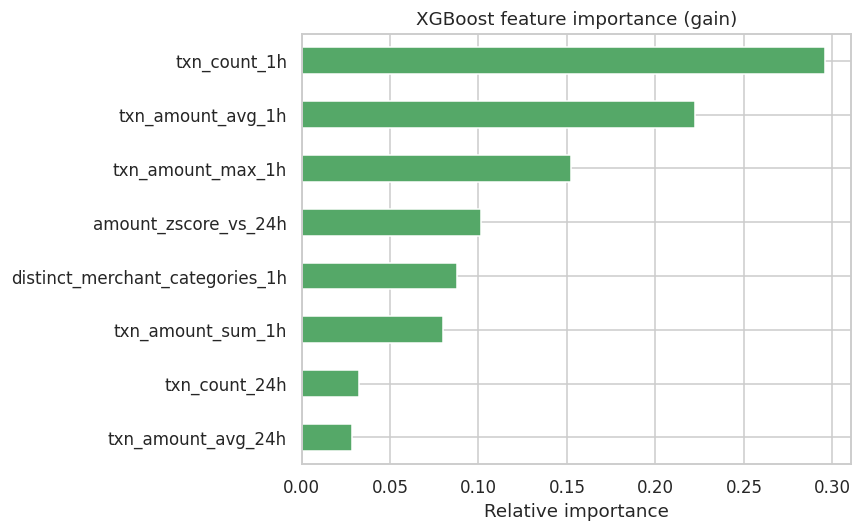

In [10]:
importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color="#55A868")
ax.set_title("XGBoost feature importance (gain)")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()


### 4.4 Calibration

A fraud score isn't just a ranking signal in this system — `api/scoring.py`
compares it directly against fixed thresholds (`FLAG` at 0.75, `BLOCK` at
0.92). That only makes sense if the score is reasonably well-calibrated as a
probability, so we check it directly.

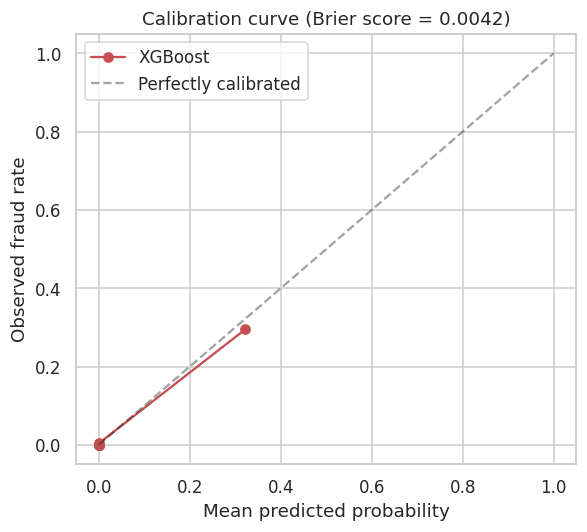

In [11]:
prob_true, prob_pred = calibration_curve(y_test, xgb_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(prob_pred, prob_true, "o-", color="#C44E52", label="XGBoost")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraud rate")
ax.set_title(f"Calibration curve (Brier score = {brier_score_loss(y_test, xgb_proba):.4f})")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Threshold Selection — A Cost-Based View

Precision/recall alone don't tell you where to set the threshold — that
requires attaching a cost to each error type:

- **False negative** (missed fraud): average fraud loss ≈ \$400
- **False positive** (legitimate txn flagged): customer friction / support
  cost ≈ \$8

We sweep thresholds and pick the one minimizing total expected cost, then
compare it to the default shipped in `api/scoring.py`.

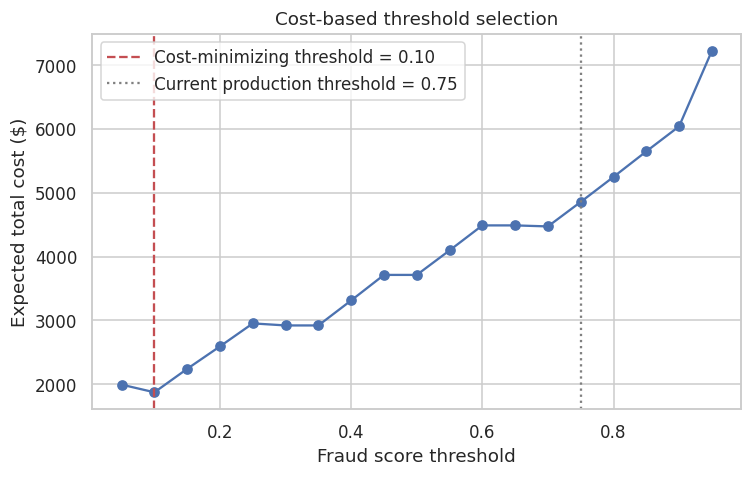

Cost-minimizing threshold: 0.10  (current production default: 0.75)


In [12]:
FN_COST = 400
FP_COST = 8

thresholds = np.linspace(0.05, 0.95, 19)
costs = []

for t in thresholds:
    preds = (xgb_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost = fn * FN_COST + fp * FP_COST
    costs.append(total_cost)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, costs, marker="o", color="#4C72B0")
ax.axvline(best_threshold, color="#C44E52", linestyle="--",
           label=f"Cost-minimizing threshold = {best_threshold:.2f}")
ax.axvline(FRAUD_SCORE_THRESHOLD, color="gray", linestyle=":",
           label=f"Current production threshold = {FRAUD_SCORE_THRESHOLD}")
ax.set_xlabel("Fraud score threshold")
ax.set_ylabel("Expected total cost ($)")
ax.set_title("Cost-based threshold selection")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Cost-minimizing threshold: {best_threshold:.2f}  (current production default: {FRAUD_SCORE_THRESHOLD})")


## Conclusions

- Fraud is well-separated from legitimate activity primarily via
  `amount_zscore_vs_24h` and short-window transaction velocity
  (`txn_count_1h`, `distinct_merchant_categories_1h`) — consistent with how
  the synthetic fraud patterns (card testing, amount anomalies, category
  jumps) were designed in the producer.
- XGBoost meaningfully outperforms the logistic regression baseline on
  PR-AUC, justifying the added complexity for this problem.
- The model's probability outputs are reasonably well-calibrated, which
  matters because `api/scoring.py` treats the score as an absolute
  probability against fixed thresholds, not just a ranking signal.
- The cost-based analysis suggests the current production threshold is in a
  reasonable range, but should be revisited once real (not synthetic) fraud
  loss and support-cost figures are available.

**Next steps:** retrain on real streamed features once `make demo` has been
run for long enough to populate the offline store, and re-run this notebook
against that data instead of the synthetic fallback.